# Notebook 07: Candidate Models and Hyperparameter Tuning

**Project:** NFL Wide Receiver Performance and Contract Value Analysis  
**Authors:** William Reed and Jason Kuzmission  
**Primary Notebook Developer:** William Reed  

## Purpose

This notebook extends the baseline modeling work from Notebook 06 by
evaluating additional tunable machine learning models for predicting
next season NFL wide receiver receiving yards.

The analysis uses the same finalized modeling dataset and preserves the
player grouped validation strategy established earlier in the project.
Grouping by player prevents observations from the same player from appearing
in both training and testing data, reducing the risk of data leakage and
providing a more realistic estimate of performance on unseen players.

The objective is to determine whether a tuned nonlinear model improves
predictive performance over the baseline approaches while maintaining
appropriate controls for overfitting and data leakage.

In [1]:
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

In [2]:
def evaluate_model(y_true, y_pred):
    """Calculate regression evaluation metrics."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

In [3]:
# Load the finalized modeling dataset
data_path = Path("../data/processed/wr_model.csv")

wr_model = pl.read_csv(data_path)

print(f"Dataset shape: {wr_model.shape}")
print(f"Rows: {wr_model.height:,}")
print(f"Columns: {wr_model.width:,}")

required_columns = [
    "player_id",
    "receiving_yards",
    "next_season_receiving_yards",
]

for column in required_columns:
    assert column in wr_model.columns, f"{column} is missing from the dataset."

print("Required columns verified.")

Dataset shape: (2127, 141)
Rows: 2,127
Columns: 141
Required columns verified.


In [4]:
groups = wr_model["player_id"].to_numpy()

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(wr_model, groups=groups)
)

In [5]:
# Define predictors, target, and grouping variable

target_column = "next_season_receiving_yards"
group_column = "player_id"

predictor_columns = [
    column
    for column in wr_model.columns
    if column not in [target_column, group_column]
]

print(f"Predictor variables: {len(predictor_columns)}")
print(f"Target: {target_column}")
print(f"Grouping variable: {group_column}")

assert len(predictor_columns) == 139, (
    f"Expected 139 predictors, found {len(predictor_columns)}."
)

assert target_column not in predictor_columns
assert group_column not in predictor_columns

print("Predictor definition verified.")

Predictor variables: 139
Target: next_season_receiving_yards
Grouping variable: player_id
Predictor definition verified.


In [6]:
# Create grouped training and testing datasets

train_data = wr_model[train_idx]
test_data = wr_model[test_idx]

train_players = set(train_data["player_id"].to_list())
test_players = set(test_data["player_id"].to_list())

player_overlap = train_players.intersection(test_players)

print(f"Training observations: {train_data.height:,}")
print(f"Testing observations: {test_data.height:,}")
print(f"Training players: {len(train_players)}")
print(f"Testing players: {len(test_players)}")
print(f"Player overlap: {len(player_overlap)}")

assert len(player_overlap) == 0, "Players overlap between training and testing sets."

Training observations: 1,683
Testing observations: 444
Training players: 495
Testing players: 124
Player overlap: 0


In [7]:
# Create predictor and target datasets

X_train = train_data.select(predictor_columns)
X_test = test_data.select(predictor_columns)

y_train = train_data[target_column].to_numpy()
y_test = test_data[target_column].to_numpy()

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train observations: {len(y_train):,}")
print(f"y_test observations: {len(y_test):,}")

assert X_train.shape == (1683, 139)
assert X_test.shape == (444, 139)
assert len(y_train) == 1683
assert len(y_test) == 444

print("Feature and target datasets verified.")

X_train shape: (1683, 139)
X_test shape: (444, 139)
y_train observations: 1,683
y_test observations: 444
Feature and target datasets verified.


In [8]:
# Median imputation using training data only

median_imputer = SimpleImputer(strategy="median")

# Fit only on training predictors
X_train_imputed = median_imputer.fit_transform(X_train.to_numpy())

# Apply training-learned medians to testing predictors
X_test_imputed = median_imputer.transform(X_test.to_numpy())

print(f"Training shape after imputation: {X_train_imputed.shape}")
print(f"Testing shape after imputation: {X_test_imputed.shape}")

print(
    f"Training missing values after imputation: "
    f"{np.isnan(X_train_imputed).sum():,}"
)

print(
    f"Testing missing values after imputation: "
    f"{np.isnan(X_test_imputed).sum():,}"
)

assert X_train_imputed.shape == (1683, 139)
assert X_test_imputed.shape == (444, 139)
assert np.isnan(X_train_imputed).sum() == 0
assert np.isnan(X_test_imputed).sum() == 0

print("Median imputation verified.")

Training shape after imputation: (1683, 139)
Testing shape after imputation: (444, 139)
Training missing values after imputation: 0
Testing missing values after imputation: 0
Median imputation verified.


## Baseline Model Results

Before testing the candidate models, we will use the results from Notebook 06 as our baseline for comparison.

| Model | MAE | RMSE | R-squared |
|---|---:|---:|---:|
| Historical Persistence | 234.68 | 323.45 | 0.416 |
| Multiple Linear Regression | 220.52 | 302.60 | 0.488 |

The multiple linear regression model performed better than the historical persistence baseline on all three evaluation metrics. Because of this, it will serve as the main benchmark for the candidate models tested in this notebook.

The goal is to determine whether models that can capture more complex relationships in the data can improve prediction of next-season receiving yards for players who were not included in the training data.

## Random Forest Regression

We will first fit a basic Random Forest model using the same training and testing data used for the baseline models. This gives us an initial result before making any changes to the model's hyperparameters.

In [9]:
# Fit an initial Random Forest model

random_forest = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train_imputed, y_train)

rf_predictions = random_forest.predict(X_test_imputed)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest R-squared: {rf_r2:.3f}")

Random Forest MAE: 217.77
Random Forest RMSE: 289.85
Random Forest R-squared: 0.531


In [10]:
# Evaluate Random Forest training performance

rf_train_predictions = random_forest.predict(X_train_imputed)

rf_train_mae = mean_absolute_error(y_train, rf_train_predictions)
rf_train_rmse = np.sqrt(
    mean_squared_error(y_train, rf_train_predictions)
)
rf_train_r2 = r2_score(y_train, rf_train_predictions)

print(f"Training MAE: {rf_train_mae:.2f}")
print(f"Training RMSE: {rf_train_rmse:.2f}")
print(f"Training R-squared: {rf_train_r2:.3f}")

print("\nHeld-out Test Performance")
print(f"Test MAE: {rf_mae:.2f}")
print(f"Test RMSE: {rf_rmse:.2f}")
print(f"Test R-squared: {rf_r2:.3f}")

Training MAE: 74.51
Training RMSE: 98.07
Training R-squared: 0.939

Held-out Test Performance
Test MAE: 217.77
Test RMSE: 289.85
Test R-squared: 0.531


### Initial Random Forest Results

The initial Random Forest improved held-out test performance compared with the linear regression baseline. Test MAE decreased from 220.52 to 217.77, RMSE decreased from 302.60 to 289.85, and R-squared increased from 0.488 to 0.531.

However, the model performed much better on the training data than on the held-out test data. Training R-squared was 0.939 compared with 0.531 on the test set. The large difference between training and testing performance indicates that the initial Random Forest is overfitting.

The next step is to adjust a small number of Random Forest hyperparameters to reduce model complexity and determine whether performance on unseen players can be improved.

In [11]:
# Set up grouped cross-validation for Random Forest tuning

train_groups = train_data[group_column].to_numpy()

group_cv = GroupKFold(n_splits=5)

print(f"Cross-validation folds: {group_cv.get_n_splits()}")
print(f"Training observations available for tuning: {len(y_train):,}")
print(f"Unique training players: {len(np.unique(train_groups)):,}")

assert len(train_groups) == len(y_train)
assert len(np.unique(train_groups)) == 495

print("Grouped cross-validation setup verified.")

Cross-validation folds: 5
Training observations available for tuning: 1,683
Unique training players: 495
Grouped cross-validation setup verified.


In [12]:
# Define Random Forest hyperparameter search space

rf_param_grid = {
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5, 1.0],
}

total_combinations = (
    len(rf_param_grid["max_depth"])
    * len(rf_param_grid["min_samples_split"])
    * len(rf_param_grid["min_samples_leaf"])
    * len(rf_param_grid["max_features"])
)

print(f"Random Forest parameter combinations: {total_combinations}")

Random Forest parameter combinations: 108


In [13]:
# Build leakage-safe Random Forest tuning pipeline

rf_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestRegressor(
                n_estimators=500,
                random_state=42,
                n_jobs=-1
            )
        ),
    ]
)

rf_search_params = {
    "model__max_depth": rf_param_grid["max_depth"],
    "model__min_samples_split": rf_param_grid["min_samples_split"],
    "model__min_samples_leaf": rf_param_grid["min_samples_leaf"],
    "model__max_features": rf_param_grid["max_features"],
}

print("Random Forest tuning pipeline created.")

Random Forest tuning pipeline created.


In [14]:
# Configure grouped Random Forest hyperparameter search

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_search_params,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=group_cv,
    random_state=42,
    n_jobs=1,
    verbose=1,
    return_train_score=True
)

print("Random Forest randomized search configured.")
print("Parameter combinations to test: 20")
print("Grouped CV folds: 5")
print("Total model fits: 100")

Random Forest randomized search configured.
Parameter combinations to test: 20
Grouped CV folds: 5
Total model fits: 100


In [15]:
# Run grouped Random Forest hyperparameter search

rf_search.fit(
    X_train.to_numpy(),
    y_train,
    groups=train_groups
)

print("Random Forest tuning completed.")

print("\nBest parameters:")
for parameter, value in rf_search.best_params_.items():
    print(f"{parameter}: {value}")

best_cv_mae = -rf_search.best_score_

print(f"\nBest grouped CV MAE: {best_cv_mae:.2f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Random Forest tuning completed.

Best parameters:
model__min_samples_split: 5
model__min_samples_leaf: 5
model__max_features: 1.0
model__max_depth: 15

Best grouped CV MAE: 202.93


In [16]:
# Evaluate tuned Random Forest on held-out test data

best_rf = rf_search.best_estimator_

tuned_rf_predictions = best_rf.predict(X_test.to_numpy())

tuned_rf_mae = mean_absolute_error(y_test, tuned_rf_predictions)
tuned_rf_rmse = np.sqrt(
    mean_squared_error(y_test, tuned_rf_predictions)
)
tuned_rf_r2 = r2_score(y_test, tuned_rf_predictions)

print(f"Tuned Random Forest MAE: {tuned_rf_mae:.2f}")
print(f"Tuned Random Forest RMSE: {tuned_rf_rmse:.2f}")
print(f"Tuned Random Forest R-squared: {tuned_rf_r2:.3f}")

Tuned Random Forest MAE: 214.20
Tuned Random Forest RMSE: 286.62
Tuned Random Forest R-squared: 0.541


In [17]:
# Compare tuned Random Forest training and testing performance

tuned_rf_train_predictions = best_rf.predict(X_train.to_numpy())

tuned_rf_train_mae = mean_absolute_error(
    y_train,
    tuned_rf_train_predictions
)

tuned_rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tuned_rf_train_predictions
    )
)

tuned_rf_train_r2 = r2_score(
    y_train,
    tuned_rf_train_predictions
)

print(f"Tuned Training MAE: {tuned_rf_train_mae:.2f}")
print(f"Tuned Training RMSE: {tuned_rf_train_rmse:.2f}")
print(f"Tuned Training R-squared: {tuned_rf_train_r2:.3f}")

print("\nTuned Held-out Test Performance")
print(f"Test MAE: {tuned_rf_mae:.2f}")
print(f"Test RMSE: {tuned_rf_rmse:.2f}")
print(f"Test R-squared: {tuned_rf_r2:.3f}")

Tuned Training MAE: 117.22
Tuned Training RMSE: 158.61
Tuned Training R-squared: 0.839

Tuned Held-out Test Performance
Test MAE: 214.20
Test RMSE: 286.62
Test R-squared: 0.541


### Tuned Random Forest Results

The tuned Random Forest improved on both the linear regression baseline and the initial Random Forest. On the held-out test set, the tuned model produced an MAE of 214.20 yards, an RMSE of 286.62 yards, and an R-squared of 0.541.

Tuning also reduced the difference between training and testing performance. Training R-squared decreased from 0.939 for the initial Random Forest to 0.839 for the tuned model, while test R-squared increased from 0.531 to 0.541. The model still fits the training data better than the test data, but the smaller gap suggests that the tuning process reduced some of the overfitting seen in the initial model.

At this stage, the tuned Random Forest has the best held-out test performance of the models evaluated so far.

## Gradient Boosting Regression

The model will be evaluated using the same player grouped validation strategy and the same MAE, RMSE, and R-squared metrics used for the other models. Hyperparameter decisions will be made using the training data, while the held out test set will remain separate for final evaluation.

In [18]:
# Fit initial Gradient Boosting model

gradient_boosting = GradientBoostingRegressor(
    random_state=42
)

gradient_boosting.fit(
    X_train_imputed,
    y_train
)

gb_predictions = gradient_boosting.predict(
    X_test_imputed
)

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print(f"Gradient Boosting MAE: {gb_mae:.2f}")
print(f"Gradient Boosting RMSE: {gb_rmse:.2f}")
print(f"Gradient Boosting R-squared: {gb_r2:.3f}")

Gradient Boosting MAE: 220.30
Gradient Boosting RMSE: 293.96
Gradient Boosting R-squared: 0.517


In [19]:
# Compare initial Gradient Boosting training and testing performance

gb_train_predictions = gradient_boosting.predict(
    X_train_imputed
)

gb_train_mae = mean_absolute_error(
    y_train,
    gb_train_predictions
)

gb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        gb_train_predictions
    )
)

gb_train_r2 = r2_score(
    y_train,
    gb_train_predictions
)

print(f"Training MAE: {gb_train_mae:.2f}")
print(f"Training RMSE: {gb_train_rmse:.2f}")
print(f"Training R-squared: {gb_train_r2:.3f}")

print("\nHeld-out Test Performance")
print(f"Test MAE: {gb_mae:.2f}")
print(f"Test RMSE: {gb_rmse:.2f}")
print(f"Test R-squared: {gb_r2:.3f}")

Training MAE: 153.06
Training RMSE: 198.21
Training R-squared: 0.749

Held-out Test Performance
Test MAE: 220.30
Test RMSE: 293.96
Test R-squared: 0.517


In [20]:
# Define Gradient Boosting hyperparameter search space

gb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.10],
    "max_depth": [2, 3, 4],
    "min_samples_leaf": [3, 5, 10],
}

gb_parameter_combinations = np.prod(
    [len(values) for values in gb_param_grid.values()]
)

print(
    f"Gradient Boosting parameter combinations: "
    f"{gb_parameter_combinations}"
)

Gradient Boosting parameter combinations: 81


In [21]:
# Build leakage-safe Gradient Boosting pipeline

gb_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

gb_search_params = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.03, 0.05, 0.10],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [3, 5, 10],
}

print("Gradient Boosting pipeline configured.")
print(
    "Search-space combinations: "
    f"{np.prod([len(v) for v in gb_search_params.values()])}"
)

Gradient Boosting pipeline configured.
Search-space combinations: 81


In [22]:
# Configure grouped Gradient Boosting hyperparameter search

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_search_params,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Gradient Boosting randomized search configured.")
print("Parameter combinations to test: 20")
print("Grouped CV folds: 5")
print("Total model fits: 100")

Gradient Boosting randomized search configured.
Parameter combinations to test: 20
Grouped CV folds: 5
Total model fits: 100


In [23]:
# Run grouped Gradient Boosting hyperparameter search

gb_search.fit(
    X_train.to_numpy(),
    y_train,
    groups=train_groups
)

print("Gradient Boosting tuning completed.")

print("\nBest parameters:")
for parameter, value in gb_search.best_params_.items():
    print(f"{parameter}: {value}")

best_gb_cv_mae = -gb_search.best_score_

print(f"\nBest grouped CV MAE: {best_gb_cv_mae:.2f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Gradient Boosting tuning completed.

Best parameters:
model__n_estimators: 300
model__min_samples_leaf: 10
model__max_depth: 2
model__learning_rate: 0.05

Best grouped CV MAE: 195.61


In [24]:
# Evaluate tuned Gradient Boosting on held-out test data

best_gb = gb_search.best_estimator_

tuned_gb_predictions = best_gb.predict(
    X_test.to_numpy()
)

tuned_gb_mae = mean_absolute_error(
    y_test,
    tuned_gb_predictions
)

tuned_gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_gb_predictions
    )
)

tuned_gb_r2 = r2_score(
    y_test,
    tuned_gb_predictions
)

print(f"Tuned Gradient Boosting MAE: {tuned_gb_mae:.2f}")
print(f"Tuned Gradient Boosting RMSE: {tuned_gb_rmse:.2f}")
print(f"Tuned Gradient Boosting R-squared: {tuned_gb_r2:.3f}")

Tuned Gradient Boosting MAE: 212.33
Tuned Gradient Boosting RMSE: 284.28
Tuned Gradient Boosting R-squared: 0.549


In [25]:
# Compare tuned Gradient Boosting training and testing performance

tuned_gb_train_predictions = best_gb.predict(
    X_train.to_numpy()
)

tuned_gb_train_mae = mean_absolute_error(
    y_train,
    tuned_gb_train_predictions
)

tuned_gb_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tuned_gb_train_predictions
    )
)

tuned_gb_train_r2 = r2_score(
    y_train,
    tuned_gb_train_predictions
)

print(f"Tuned Training MAE: {tuned_gb_train_mae:.2f}")
print(f"Tuned Training RMSE: {tuned_gb_train_rmse:.2f}")
print(f"Tuned Training R-squared: {tuned_gb_train_r2:.3f}")

print("\nTuned Held-out Test Performance")
print(f"Test MAE: {tuned_gb_mae:.2f}")
print(f"Test RMSE: {tuned_gb_rmse:.2f}")
print(f"Test R-squared: {tuned_gb_r2:.3f}")

Tuned Training MAE: 166.25
Tuned Training RMSE: 218.15
Tuned Training R-squared: 0.696

Tuned Held-out Test Performance
Test MAE: 212.33
Test RMSE: 284.28
Test R-squared: 0.549


### Tuned Gradient Boosting Results

Tuning improved the Gradient Boosting model on the held-out test set. The tuned model produced an MAE of 212.33 yards, an RMSE of 284.28 yards, and an R-squared of 0.549.

The difference between training and testing performance was also smaller after tuning. Training R-squared was 0.696 compared with 0.549 on the held-out test set. This suggests that the tuned model maintained a better balance between fitting the training data and generalizing to players that were not included in training.

The tuned Gradient Boosting model produced the best held-out test results of the models evaluated so far, although its improvement over the tuned Random Forest was relatively small.

In [26]:
# Create final held-out model comparison table

model_comparison = pl.DataFrame({
    "model": [
        "Historical Persistence",
        "Multiple Linear Regression",
        "Untuned Random Forest",
        "Tuned Random Forest",
        "Untuned Gradient Boosting",
        "Tuned Gradient Boosting",
    ],
    "mae": [
        234.68,
        220.52,
        rf_mae,
        tuned_rf_mae,
        gb_mae,
        tuned_gb_mae,
    ],
    "rmse": [
        323.45,
        302.60,
        rf_rmse,
        tuned_rf_rmse,
        gb_rmse,
        tuned_gb_rmse,
    ],
    "r_squared": [
        0.416,
        0.488,
        rf_r2,
        tuned_rf_r2,
        gb_r2,
        tuned_gb_r2,
    ],
}).sort("mae")

model_comparison

model,mae,rmse,r_squared
str,f64,f64,f64
"""Tuned Gradient Boosting""",212.327576,284.283965,0.548541
"""Tuned Random Forest""",214.197765,286.616482,0.541102
"""Untuned Random Forest""",217.773514,289.846626,0.5307
"""Untuned Gradient Boosting""",220.297565,293.958644,0.51729
"""Multiple Linear Regression""",220.52,302.6,0.488
"""Historical Persistence""",234.68,323.45,0.416


## Model Comparison and Selection

The tuned Gradient Boosting model produced the best results on the held-out test set. It had the lowest MAE at 212.33 yards, the lowest RMSE at 284.28 yards, and the highest R-squared at 0.549.

The tuned Random Forest was a close second, with an MAE of 214.20 yards, an RMSE of 286.62 yards, and an R-squared of 0.541. Both tuned tree-based models performed better than the multiple linear regression and historical persistence baselines.

Gradient Boosting also showed a smaller difference between its training and testing performance than the Random Forest models. Its training R-squared was 0.696 compared with 0.549 on the held-out test set.

Based on the combined results, the tuned Gradient Boosting model was selected as the strongest model evaluated in this notebook. Its improvement over the tuned Random Forest was modest, but it produced the best held-out results across all three evaluation metrics.

In [27]:
# Calculate held-out residuals for the selected model

gb_residuals = (
    y_test
    - tuned_gb_predictions
)

print(f"Mean residual: {np.mean(gb_residuals):.2f}")
print(f"Median residual: {np.median(gb_residuals):.2f}")
print(f"Residual standard deviation: {np.std(gb_residuals):.2f}")

print(f"\nLargest underprediction: {np.max(gb_residuals):.2f}")
print(f"Largest overprediction: {np.min(gb_residuals):.2f}")

Mean residual: -2.44
Median residual: -36.84
Residual standard deviation: 284.27

Largest underprediction: 1068.28
Largest overprediction: -1101.50


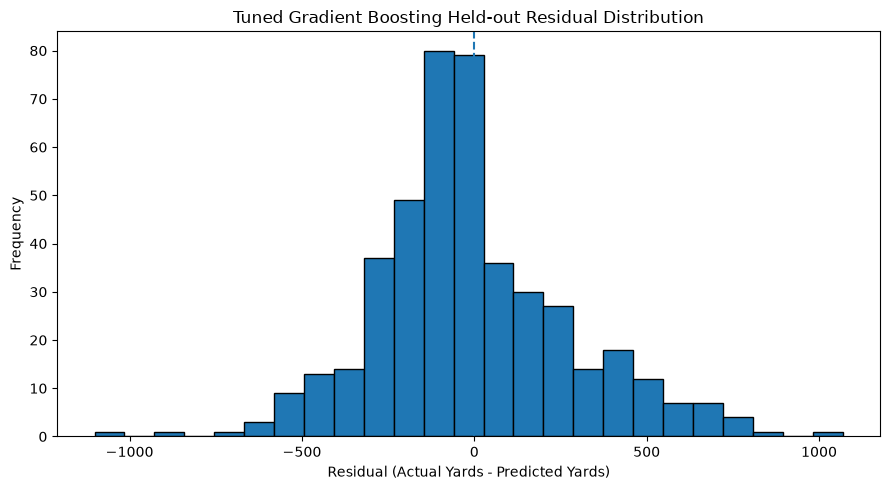

In [28]:
# Plot held-out residual distribution for tuned Gradient Boosting

plt.figure(figsize=(9, 5))

plt.hist(
    gb_residuals,
    bins=25,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Residual (Actual Yards - Predicted Yards)")
plt.ylabel("Frequency")
plt.title("Tuned Gradient Boosting Held-out Residual Distribution")

plt.tight_layout()
plt.show()

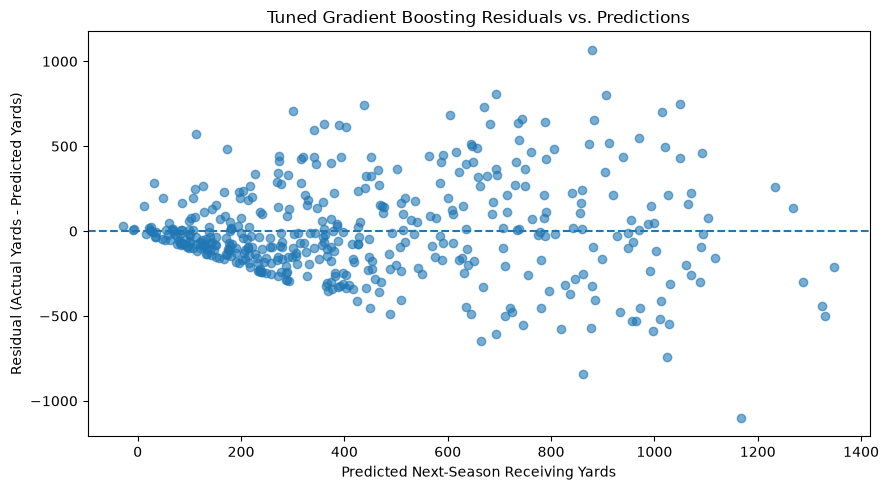

In [29]:
# Plot residuals versus predictions for tuned Gradient Boosting

plt.figure(figsize=(9, 5))

plt.scatter(
    tuned_gb_predictions,
    gb_residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Predicted Next-Season Receiving Yards")
plt.ylabel("Residual (Actual Yards - Predicted Yards)")
plt.title("Tuned Gradient Boosting Residuals vs. Predictions")

plt.tight_layout()
plt.show()

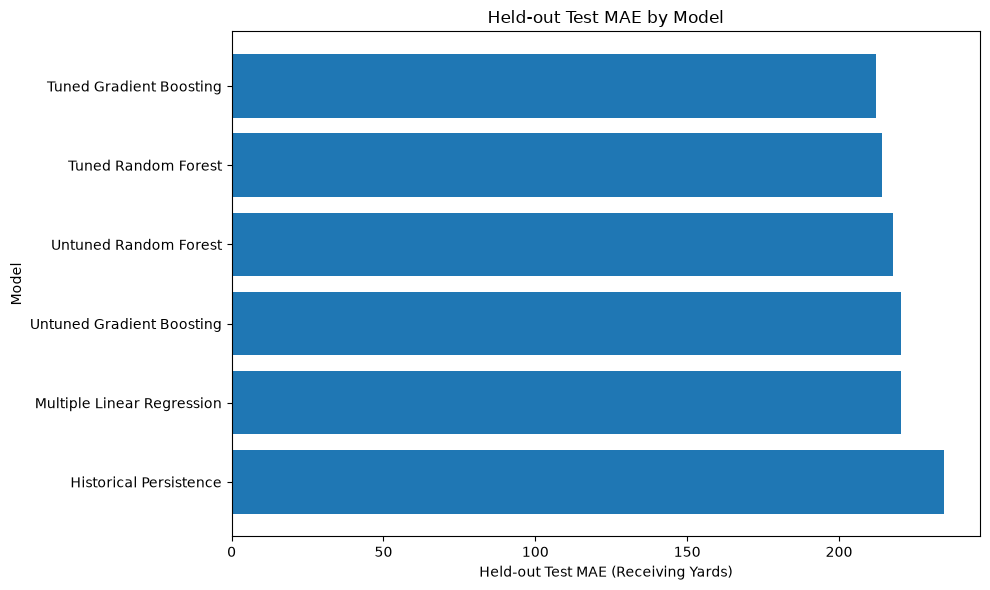

In [30]:
# Plot held-out MAE for all evaluated models

model_names = model_comparison["model"].to_list()
model_mae = model_comparison["mae"].to_list()

plt.figure(figsize=(10, 6))

plt.barh(
    model_names,
    model_mae
)

plt.xlabel("Held-out Test MAE (Receiving Yards)")
plt.ylabel("Model")
plt.title("Held-out Test MAE by Model")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Notebook 07 Summary

Random Forest and Gradient Boosting were evaluated as candidate models for predicting next season receiving yards. Both models were tested before and after hyperparameter tuning, while keeping the same player grouped training and held-out test sets established for the baseline models. Hyperparameter searches used five fold grouped cross validation so that seasons from the same player remained together within each fold.

Tuning improved both tree based models. The tuned Random Forest achieved a held-out MAE of 214.20 yards, RMSE of 286.62 yards, and R-squared of 0.541. The tuned Gradient Boosting model produced the strongest overall held-out performance, with an MAE of 212.33 yards, RMSE of 284.28 yards, and R-squared of 0.549.

The tuned Gradient Boosting model was selected as the current best model because it had the lowest held-out MAE and RMSE and the highest held-out R-squared of the models evaluated. Its training R-squared of 0.696 was also much closer to its held-out R-squared than the Random Forest results, suggesting better generalization and less overfitting.

Residual diagnostics showed little overall directional bias, with a mean residual of -2.44 yards. However, prediction errors became more variable at higher predicted receiving yard totals, and several large errors remained in both directions. This suggests that the model is less precise for receivers with unusually high or changing production.

Overall, the candidate models improved on the historical persistence and multiple linear regression baselines, although the gains were modest. Tuned Gradient Boosting will therefore serve as the current best performance model as the project moves toward further evaluation and the later contract-risk analysis.